In [1]:
# Combined Raman training + prediction + Uncertainty analysis
# Original code structure preserved; only np.save/np.load lines are commented/rewired

# Import some libraries

import torch
from torch.utils.data import Dataset, DataLoader, random_split, Subset

import numpy as np
import numpy as np
import tifffile

# import tensorly as tl
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.fft
import torch.optim as optim

# Ensure you have the correct path to your data files
# Load the synthetic CARS and Raman spectra data
raw_cars = np.load(r"C:\Users\mukhe\OneDrive\Desktop\INTERNSHIP REPORT\cars_2000x1024.npy")
raman = np.load(r"C:\Users\mukhe\OneDrive\Desktop\INTERNSHIP REPORT\raman_2000x1024.npy")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [2]:
class SpectraDataset(Dataset):
    def __init__(self, cars, raman, scale_type="minmax"):
        """
        Args:
            cars (np.array): Array of CARS spectra, shape (N, s)
            raman (np.array): Array of Raman spectra, shape (N, s)
            scale_type (str): Scaling method ('minmax', 'standard', 'log')
        """
        self.scale_type = scale_type

        # Apply scaling
        if scale_type == "minmax":
            self.cars = self.minmax_scale(cars)
            self.raman = self.minmax_scale(raman)
        elif scale_type == "standard":
            self.cars = self.standardize(cars)
            self.raman = self.standardize(raman)
        elif scale_type == "log":
            self.cars = self.log_transform(cars)
            self.raman = self.log_transform(raman)
        elif scale_type == "none":
            self.cars = cars
            self.raman = raman
        else:
            raise ValueError(
                "Invalid scale_type. Choose from ['minmax', 'standard', 'log']"
            )

        # Convert to torch tensors
        self.cars = torch.tensor(self.cars, dtype=torch.float32)
        self.raman = torch.tensor(self.raman, dtype=torch.float32)

    def minmax_scale(self, data):
        return (data - np.min(data, axis=0)) / (np.max(data, axis=0) - np.min(data, axis=0))

    def standardize(self, data):
        return (data - np.mean(data, axis=0)) / np.std(data, axis=0)

    def log_transform(self, data):
        return np.log1p(data)

    def __len__(self):
        return self.cars.shape[0]

    def __getitem__(self, idx):
        return self.cars[idx], self.raman[idx]



In [3]:
# Create the dataset
dataset = SpectraDataset(raw_cars, raman)

# Split into train and test sets (e.g., 80% train, 20% test)
train_ratio = 0.8
train_size = int(train_ratio * len(dataset)) # e.g. 1600
test_size = len(dataset) - train_size  # e.g. 400

all_indices   = np.arange(len(dataset))
train_indices = all_indices[:train_size]    # 0 ... 1599
test_indices  = all_indices[train_size:]    # 1600 ... 1999

# save test indices (for y_true later)
# np.save(r"C:\Users\mukhe\OneDrive\Desktop\INTERNSHIP REPORT\test_indices.npy",
#         test_indices)  # commented out to avoid saving to disk


# raw numpy arrays
cars_raw = raw_cars
raman_raw = raman


# extract raw train/test
cars_train = cars_raw[train_indices]
raman_train = raman_raw[train_indices]

cars_test = cars_raw[test_indices]
raman_test = raman_raw[test_indices]

# build Subset datasets using these indices
train_dataset = Subset(dataset, train_indices)
test_dataset  = Subset(dataset, test_indices)

# Create DataLoaders for batching
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Example: iterate over one batch from the training loader and print shapes
for cars_batch, raman_batch in train_loader:
    print("#")
    print("CARS batch shape:", cars_batch.shape)  # should be (batch_size, s)
    print("Raman batch shape:", raman_batch.shape)  # should be (batch_size, s)
    break
print(device)


#
CARS batch shape: torch.Size([32, 1024])
Raman batch shape: torch.Size([32, 1024])
cuda


In [4]:
# ===== CELL SEPARATOR =====

class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=None):
        #strides [1] row , [2] is column in 2d tensor
        super(ResidualBlock1D, self).__init__()
        if padding is None:
            padding = kernel_size // 2  # maintain same length
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=padding)
        self.bn1 = nn.BatchNorm1d(out_channels)
        # Batch Normalization (BatchNorm) is a layer in PyTorch that normalizes the activations of a neural network during training.
        # In simple words:
        #BatchNorm keeps the values inside the network stable.
        #This helps the model learn faster, smoother, and better.
        
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride=1, padding=padding)
        self.bn2 = nn.BatchNorm1d(out_channels)
        # Downsample if dimensions differ
        if in_channels != out_channels or stride != 1:
            self.downsample = nn.Sequential(nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride),nn.BatchNorm1d(out_channels),)
        else:
            self.downsample = None

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


In [5]:
class DualOutputResNet1D(nn.Module):
    def __init__(self, input_length, num_channels=64, num_blocks=4):
        """
        input_length: number of spectral points (e.g., 2000)
        num_channels: number of channels used in convolution layers
        num_blocks: number of residual blocks
        """
        super(DualOutputResNet1D, self).__init__()
        # Initial convolution: from 1 channel to num_channels
        self.initial_conv = nn.Sequential(
            nn.Conv1d(1, num_channels, kernel_size=7, stride=2, padding=3),
            nn.BatchNorm1d(num_channels),
            nn.ReLU(inplace=True),
        )
        # MaxPool to further reduce length
        self.maxpool = nn.MaxPool1d(kernel_size=3, stride=2, padding=1)

        # Build several residual blocks
        blocks = []
        for _ in range(num_blocks):
            blocks.append(ResidualBlock1D(num_channels, num_channels, kernel_size=3))
        self.res_blocks = nn.Sequential(*blocks)

        # Two output heads for resonant and NRB estimates.
        # Each head maps from num_channels to 1 channel using a 1x1 conv.
        self.fc_res = nn.Conv1d(num_channels, 1, kernel_size=1)
        self.fc_nrb = nn.Conv1d(num_channels, 1, kernel_size=1)

        # Upsample layer to restore original resolution.
        # With stride 2 then maxpool (stride 2), the output length becomes ~input_length/4.
        # We upsample by a factor of 4.
        self.upsample = nn.Upsample(scale_factor=4, mode="linear", align_corners=True)
        self.alpha = nn.Parameter(torch.tensor(1.0))
        self.beta = nn.Parameter(torch.tensor(0.0))

    def forward(self, x):
        """
        x: Tensor of shape (batch, s)
        Returns:
          y_pred: predicted Raman spectrum (resonant component), shape (batch, s)
          y_res: resonant branch output, shape (batch, s)
          y_nrb: NRB estimate, shape (batch, s)
        """
        # Unsqueeze to add channel dimension: (batch, 1, s)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        out = self.initial_conv(x)  # shape: (batch, num_channels, s/2)
        out = self.maxpool(out)  # shape: (batch, num_channels, s/4) approximately
        out = self.res_blocks(out)  # shape: (batch, num_channels, s/4)

        # Generate branch outputs
        y_res = self.fc_res(out)  # shape: (batch, 1, s/4)
        y_nrb = self.fc_nrb(out)  # shape: (batch, 1, s/4)

        # Upsample back to original spectral length
        y_res = self.upsample(y_res)  # shape: (batch, 1, s)
        y_nrb = self.upsample(y_nrb)  # shape: (batch, 1, s)

        # Squeeze the channel dimension: (batch, s)
        y_res = y_res.squeeze(1)
        y_nrb = y_nrb.squeeze(1)

        # The final predicted Raman is taken as the resonant component.
        # y_pred = y_res
        return y_res, y_nrb


In [6]:
def hilbert_transform(x):
    """
    Compute the Hilbert transform along the last dimension.
    x: Tensor of shape (batch, s) (real-valued)
    Returns: Tensor of shape (batch, s) representing the imaginary part of the analytic signal.
    """
    # x = 0.5 * torch.log(x)
    X = torch.fft.fft(x, dim=-1)
    n = x.shape[-1]
    h = torch.zeros(n, device=x.device, dtype=X.dtype)
    if n % 2 == 0:
        h[0] = 1.0
        h[1 : n // 2] = 2.0
        h[n // 2] = 1.0
    else:
        h[0] = 1.0
        h[1 : (n + 1) // 2] = 2.0
    X = X * h
    x_analytic = torch.fft.ifft(X, dim=-1)
    return x_analytic.imag


def composite_loss(y_raman, y_res, y_nrb, x_cars, lambdas):
    """
    y_pred: predicted Raman spectrum (from resonant branch) [batch, s]
    y_raman: ground truth Raman spectrum [batch, s]
    y_res: resonant component predicted by the network [batch, s]
    y_nrb: predicted non-resonant background [batch, s]
    x_cars: input raw CARS spectrum [batch, s]
    lambdas: dictionary with loss weights for 'mse', 'kk', and 'nrb'
    """
    # Fidelity Loss: Mean Squared Error between predicted Raman and ground truth.
    mse_loss = torch.mean((y_res - y_raman) ** 2)

    # KK Loss: enforce that the resonant part matches the Hilbert transform of (CARS - NRB).
    resonant_estimate = x_cars - y_nrb
    expected_raman = hilbert_transform(resonant_estimate)
    kk_loss_val = torch.mean((y_res - expected_raman) ** 2)

    # NRB Smoothness Loss: penalize high-frequency changes in the NRB estimate.
    nrb_loss = torch.mean((y_nrb[:, 1:] - y_nrb[:, :-1]) ** 2)
    second_deriv = torch.mean((y_nrb[:, 2:] - 2 * y_nrb[:, 1:-1] + y_nrb[:, :-2]) ** 2)

    total_loss = (
        lambdas.get("mse") * mse_loss
        + lambdas.get("kk") * kk_loss_val
        + lambdas.get("nrb") * (second_deriv + nrb_loss)
    )
    return total_loss


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters

input_dim = 1024  # spectral length
learning_rate = 1e-3
num_channels = 64
num_blocks = 4
num_epochs = 5000

# Instantiate the model, optimizer, and loss weights
# model = DualOutputFNO(modes, width).to(device)
model = DualOutputResNet1D(input_dim, num_channels, num_blocks).to(device)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate)
# scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min")
lambdas = {"mse": 10, "kk": 1.0, "nrb": 10.0}

# Training loop
model.train()
for epoch in range(num_epochs):
    epoch_loss = 0.0
    for x_cars, y_raman in train_loader:
        # Move data to device
        x_cars = x_cars.to(device)  # shape: (batch, s) # batch from the 80% train subset
        y_raman = y_raman.to(device)  # shape: (batch, s)

        optimizer.zero_grad()
        y_res, y_nrb = model(x_cars) # shape: (batch, s) # <-- these are predictions ONLY for this batch
        # print(y_res.shape)
        # print(y_raman.shape)
        loss = composite_loss(y_raman, y_res, y_nrb, x_cars, lambdas)
        loss.backward()
        optimizer.step()
        # scheduler.step(loss)
        epoch_loss += loss.item()
    if epoch % 100 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss/len(train_loader):.6f}")


Epoch 1/5000, Loss: 1.433525
Epoch 101/5000, Loss: 0.017245
Epoch 201/5000, Loss: 0.011754
Epoch 301/5000, Loss: 0.009322
Epoch 401/5000, Loss: 0.008764
Epoch 501/5000, Loss: 0.007949
Epoch 601/5000, Loss: 0.007804
Epoch 701/5000, Loss: 0.007463
Epoch 801/5000, Loss: 0.007465
Epoch 901/5000, Loss: 0.007305
Epoch 1001/5000, Loss: 0.007200
Epoch 1101/5000, Loss: 0.006922
Epoch 1201/5000, Loss: 0.006965
Epoch 1301/5000, Loss: 0.006913
Epoch 1401/5000, Loss: 0.006907
Epoch 1501/5000, Loss: 0.006868
Epoch 1601/5000, Loss: 0.006813
Epoch 1701/5000, Loss: 0.006726
Epoch 1801/5000, Loss: 0.006881
Epoch 1901/5000, Loss: 0.006878
Epoch 2001/5000, Loss: 0.006768
Epoch 2101/5000, Loss: 0.006734
Epoch 2201/5000, Loss: 0.006790
Epoch 2301/5000, Loss: 0.006675
Epoch 2401/5000, Loss: 0.006709
Epoch 2501/5000, Loss: 0.006716
Epoch 2601/5000, Loss: 0.006673
Epoch 2701/5000, Loss: 0.006713
Epoch 2801/5000, Loss: 0.006647
Epoch 2901/5000, Loss: 0.006619
Epoch 3001/5000, Loss: 0.006703
Epoch 3101/5000, Los

In [8]:
def min_max_normalize(spectra, eps=1e-8):
    """
    Normalize each sample in the spectra tensor independently to the range [0, 1].

    Args:
        spectra (torch.Tensor): Input tensor of shape (batch, s).
        eps (float): Small constant to avoid division by zero.

    Returns:
        torch.Tensor: Normalized tensor of shape (batch, s).
    """
    # Compute min and max along each row (i.e. for each sample)
    min_val, _ = spectra.min(dim=1, keepdim=True)
    max_val, _ = spectra.max(dim=1, keepdim=True)
    mean_val = spectra.mean(dim=1, keepdim=True)
    normalized = (spectra - min_val) / (max_val - min_val + eps)
    return normalized

# MSE (Mean Squared Error) Measures absolute error between predicted Raman and true Raman.
# What you learn:
# How accurate your model is in absolute terms
# Good for evaluating peak intensity errors

def mse_metric(pred, true):
    """Mean Squared Error."""
    pred_n = min_max_normalize(pred)
    true_n = min_max_normalize(true)

    return torch.mean((pred_n - true_n) ** 2)



def rmse_metric(pred, true):
    """Root Mean Squared Error."""
    return torch.sqrt(mse_metric(pred, true))

# PSNR (Peak Signal-to-Noise Ratio) Tells how “clean” the predicted signal is compared to the true signal.
# Larger PSNR = better quality reconstruction 
# Typical interpretation:
# >20 dB = Good
# >30 dB = Very good
# >40 dB = Excellent

def psnr_metric(pred, true):
    """Peak Signal-to-Noise Ratio."""
    pred_n = min_max_normalize(pred)
    true_n = min_max_normalize(true)
    mse = mse_metric(pred, true)
    if mse == 0:
        return float("inf")
    max_val = torch.max(true_n)
    return 20 * torch.log10(max_val) - 10 * torch.log10(mse)

# SAM (Spectral Angle Mapper) Measures the angle between predicted and true spectra (shape similarity).
# Range: 0 = perfect match, closer to 0 = better
# What you learn:
# Shape alignment quality (not intensity)
# Whether peaks occur in correct places
# Good for spectroscopy because intensity alone is not enough

def spectral_angle_mapper(pred, true):
    """
    Spectral Angle Mapper (SAM):
    Computes the average angle (in radians) between spectral vectors at each pixel.
    A smaller SAM indicates closer spectral alignment.
    """
    # Compute dot products along the spectral dimension
    pred_n = min_max_normalize(pred)
    true_n = min_max_normalize(true)
    dot = torch.sum(pred_n * true_n, axis=-1)
    # Compute the norm of each spectral vector
    norm_pred = torch.linalg.norm(pred_n, axis=-1)
    norm_true = torch.linalg.norm(true_n, axis=-1)
    # Compute cosine similarity; add epsilon to avoid division by zero
    eps = 1e-8
    cos_angle = dot / (norm_pred * norm_true + eps)
    # Clamp values to the valid range [-1, 1] to avoid NaNs due to floating point errors
    cos_angle = torch.clip(cos_angle, -1, 1)
    angles = torch.arccos(cos_angle)
    return torch.mean(angles)


In [9]:
import torch
import numpy as np

model.eval()  # very important!
all_y_res = []
all_y_nrb = []

with torch.no_grad():
    for x_cars, _ in test_loader:   # we only need inputs here
        x_cars = x_cars.to(device)

        y_res, y_nrb = model(x_cars)   # predictions

        # move to CPU and convert to numpy
        all_y_res.append(y_res.cpu().numpy())
        all_y_nrb.append(y_nrb.cpu().numpy())

# stack all batches into one big array
y_res_test = np.concatenate(all_y_res, axis=0)   # shape: (N_samples, ..., ...)
y_nrb_test = np.concatenate(all_y_nrb, axis=0)


# Now have full test predictions in y_res_test and y_nrb_test.

In [10]:
#  UNCERTAINTY ANALYSIS

import numpy as np
import matplotlib.pyplot as plt


y_pred       = y_res_test                    
full_raman   = raman                        
# test_indices is already defined above

y_true = full_raman[test_indices]            

def normalize_per_spectrum(arr):
    # arr shape: (N_spectra, 640)
    min_vals = arr.min(axis=1, keepdims=True)
    max_vals = arr.max(axis=1, keepdims=True)
    return (arr - min_vals) / (max_vals - min_vals + 1e-8)

y_true_norm = normalize_per_spectrum(y_true)
y_pred_norm = normalize_per_spectrum(y_pred)
print("Shapes:", y_pred_norm.shape, y_true_norm.shape)

Shapes: (400, 1024) (400, 1024)


In [11]:
# 1) Split test set: 50% calib, 50% evaluation

N = y_pred_norm.shape[0]
N_cal = N // 2               # first half for calibration
N_eval = N - N_cal           # second half for evaluation

y_pred_norm_cal = y_pred_norm[:N_cal]
y_true_norm_cal = y_true_norm[:N_cal]

y_pred_norm_eval = y_pred_norm[N_cal:]
y_true_norm_eval = y_true_norm[N_cal:]

print("Calibration size:", y_pred_norm_cal.shape[0])
print("Evaluation size :", y_pred_norm_eval.shape[0])

Calibration size: 200
Evaluation size : 200


In [12]:
alpha = 0.1
scores_cal = np.abs(y_true_norm_cal - y_pred_norm_cal)

q = np.quantile(scores_cal, 1 - alpha, axis=0)

In [13]:
#========= PROBLEM WITH POINT-WISE QUANTILE ==================

# It treats each wavelength independently
# One bad spectrum at that wavelength -> large q
# That large q affects ALL spectra
# How bad can the error be at wavelength j across all spectra?

# ========= BUT IN SPECTRAM WISE =======
# How bad is the overall spectrum error?

In [14]:
# ===== Real solvents dataset (only for testing) =====

# Load real data
cars_real = np.load(r"C:\Users\mukhe\OneDrive\Desktop\INTERNSHIP REPORT\dataset_Mukesh\dataset_Mukesh\CARS_solvents_all.npy")        # (6, 1024)
raman_real = np.load(r"C:\Users\mukhe\OneDrive\Desktop\INTERNSHIP REPORT\dataset_Mukesh\dataset_Mukesh\RAMAN_solvents_all.npy")      # (6, 656)
wn = np.load(r"C:\Users\mukhe\OneDrive\Desktop\INTERNSHIP REPORT\dataset_Mukesh\dataset_Mukesh\Raman_solvent_wavenumber.npy")        # (656,)

print("cars_real shape:", cars_real.shape)
print("raman_real shape:", raman_real.shape)
print("wn shape:", wn.shape)



cars_real shape: (6, 1024)
raman_real shape: (6, 656)
wn shape: (656,)


In [15]:
import numpy as np

print("Before:", raman_real.shape)  # (6, 656)

target_len = 1024
current_len = raman_real.shape[1]

pad_width = target_len - current_len

raman_real_padded = np.pad(
    raman_real,
    pad_width=((0, 0), (0, pad_width)),  # only pad columns
    mode='constant',
    constant_values=0
)

print("After:", raman_real_padded.shape)  # (6, 1000)



Before: (6, 656)
After: (6, 1024)


In [16]:
cars_min_train = np.min(cars_train, axis=0)
cars_max_train = np.max(cars_train, axis=0)

raman_min_train = np.min(raman_train, axis=0)
raman_max_train = np.max(raman_train, axis=0)


In [17]:
cars_real_norm = (cars_real - cars_min_train) / (cars_max_train - cars_min_train)
raman_real_norm = (raman_real_padded - raman_min_train) / (raman_max_train - raman_min_train)


In [18]:
real_dataset = SpectraDataset(cars_real_norm, raman_real_norm, scale_type="none")
real_loader  = DataLoader(real_dataset, batch_size=len(real_dataset), shuffle=False)


In [19]:
model.eval()

y_true_real = []
y_pred_real = []

with torch.no_grad():
    for x_cars, y_raman in real_loader:
        x_cars = x_cars.to(device)
        y_raman = y_raman.to(device)

        pred,_ = model(x_cars)

        y_true_real.append(y_raman.cpu().numpy())
        y_pred_real.append(pred.cpu().numpy())

y_true_real = np.concatenate(y_true_real, axis=0)   # (6, 1024)
y_pred_real = np.concatenate(y_pred_real, axis=0)   # (6, 1024)

In [20]:
import numpy as np
import matplotlib.pyplot as plt

y_pred_real = y_pred_real      # (N_real, 656)
y_true_real = raman_real_norm            # (N_real, 656)

print("Real data Shapes:", y_pred_real.shape, y_true_real.shape)


Real data Shapes: (6, 1024) (6, 1024)


In [21]:
lower = y_pred_real - q
upper = y_pred_real + q


In [22]:
LEN = len(wn)   # 656

y_true_s = y_true_real[:, :LEN]
y_pred_s = y_pred_real[:, :LEN]
lower_s  = lower[:,  :LEN]
upper_s  = upper[:,  :LEN]


In [23]:
covered = (y_true_s >= lower_s) & (y_true_s <= upper_s)

coverage_overall = covered.mean()
coverage_per_spectrum = covered.mean(axis=1)

print("Overall coverage:", coverage_overall)
for i, c in enumerate(coverage_per_spectrum):
    print(f"Spectrum {i} coverage:", c)


Overall coverage: 0.726880081300813
Spectrum 0 coverage: 0.6402439024390244
Spectrum 1 coverage: 0.8094512195121951
Spectrum 2 coverage: 0.6844512195121951
Spectrum 3 coverage: 0.7240853658536586
Spectrum 4 coverage: 0.8155487804878049
Spectrum 5 coverage: 0.6875


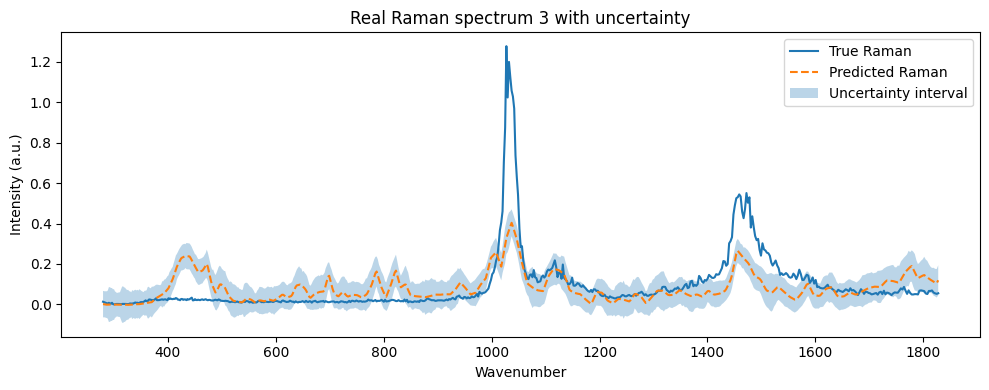

In [24]:
idx = 3

plt.figure(figsize=(10,4))

plt.plot(wn, y_true_s[idx], label="True Raman")
plt.plot(wn, y_pred_s[idx], "--", label="Predicted Raman")
plt.fill_between(
    wn,
    lower_s[idx],
    upper_s[idx],
    alpha=0.3,
    label="Uncertainty interval"
)

plt.xlabel("Wavenumber")
plt.ylabel("Intensity (a.u.)")
plt.title(f"Real Raman spectrum {idx} with uncertainty")
plt.legend()
plt.tight_layout()
plt.show()


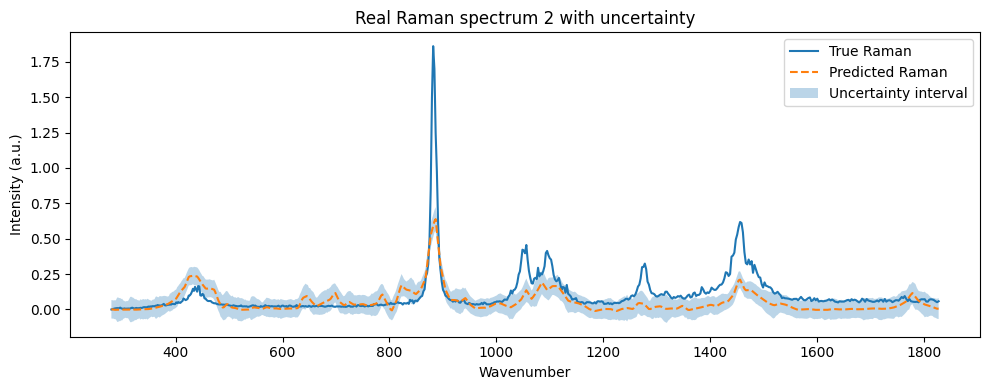

In [25]:
idx = 2

plt.figure(figsize=(10,4))

plt.plot(wn, y_true_s[idx], label="True Raman")
plt.plot(wn, y_pred_s[idx], "--", label="Predicted Raman")
plt.fill_between(
    wn,
    lower_s[idx],
    upper_s[idx],
    alpha=0.3,
    label="Uncertainty interval"
)

plt.xlabel("Wavenumber")
plt.ylabel("Intensity (a.u.)")
plt.title(f"Real Raman spectrum {idx} with uncertainty")
plt.legend()
plt.tight_layout()
plt.show()


In [44]:
# Split the test set (400 samples) into calibration (200) and evaluation (200)
# Use the same indexing logic as the existing code

cal_size  = 200
eval_size = test_size - cal_size  # 200

cal_indices  = test_indices[:cal_size]            # 1600 ... 1799
eval_indices = test_indices[cal_size:]            # 1800 ... 1999

# Extract raw CARS for each subset
X_cars_synthetic_cal  = cars_raw[cal_indices]     # 200 x 1024 (or whatever spectrum length)
X_cars_synthetic_eval = cars_raw[eval_indices]    # 200 x 1024

# Extract raw Raman for each subset (you may already have these elsewhere)
y_true_synthetic_cal  = raman_raw[cal_indices]    # 200 x 1024
y_true_synthetic_eval = raman_raw[eval_indices]   # 200 x 1024

# Verify shapes
print("X_cars_synthetic_cal shape: ", X_cars_synthetic_cal.shape)
print("X_cars_synthetic_eval shape:", X_cars_synthetic_eval.shape)
print("y_true_synthetic_cal shape: ", y_true_synthetic_cal.shape)
print("y_true_synthetic_eval shape:", y_true_synthetic_eval.shape)

X_cars_synthetic_cal shape:  (200, 1024)
X_cars_synthetic_eval shape: (200, 1024)
y_true_synthetic_cal shape:  (200, 1024)
y_true_synthetic_eval shape: (200, 1024)


In [45]:
import numpy as np
from sklearn.linear_model import LogisticRegression

def weighted_quantile(scores, weights, alpha):
    """
    Compute the (1 - alpha) weighted quantile of scores.
    
    Parameters
    ----------
    scores : array-like
        Nonconformity scores
    weights : array-like
        Importance weights (same length as scores)
    alpha : float
        Significance level (e.g., 0.1 for 90% coverage)
    
    Returns
    -------
    float : the weighted quantile threshold
    """
    idx = np.argsort(scores)
    s = scores[idx]
    w = weights[idx]
    
    cum_w = np.cumsum(w)
    cutoff = (1 - alpha) * cum_w[-1]
    
    return s[np.searchsorted(cum_w, cutoff)]

alpha = 0.1

In [46]:
# Scores are computed in the Raman space on the calibration set
# This is identical for both Option A and Option B
scores_matrix = np.abs(y_true_norm_cal - y_pred_norm_cal)
scores_cal = scores_matrix.ravel()

print(f"scores_cal shape: {scores_cal.shape}")

scores_cal shape: (204800,)


In [47]:
# Scores are computed in the Raman space on the calibration set
# This is identical for both Option A and Option B
scores_matrix_eval = np.abs(y_true_norm_eval - y_pred_norm_eval)
scores_eval = scores_matrix_eval.ravel()

print(f"scores_eval shape: {scores_eval.shape}")

scores_eval shape: (204800,)


In [48]:
# === OPTION A: Classifier on Predicted Raman ===

# Step 1: Build classifier training data from predicted Raman
Xs_A = y_pred_norm_cal.reshape(len(y_pred_norm_cal), -1)   # 200 x 1024
Xr_A = y_pred_real.reshape(len(y_pred_real), -1)           # 6 x 1024
X_clf_A = np.vstack([Xs_A, Xr_A])

# Step 2: Binary labels (0 = synthetic, 1 = real)
y_clf = np.hstack([np.zeros(len(Xs_A)), np.ones(len(Xr_A))])

# Step 3: Train logistic regression
clf_A = LogisticRegression(max_iter=300)
clf_A.fit(X_clf_A, y_clf)

# Step 4: Extract weights — apply classifier to evaluation predictions
Xt_A = y_pred_norm_eval.reshape(len(y_pred_norm_eval), -1) # 200 x 1024
p_real_A = clf_A.predict_proba(Xt_A)[:, 1]
weights_A = p_real_A / (1 - p_real_A + 1e-8)

# Step 5: Expand weights and compute weighted quantile
weights_expanded_A = np.repeat(weights_A, y_true_norm_eval.shape[1])
q_weighted_A = weighted_quantile(scores_eval, weights_expanded_A, alpha)

print(f"Option A — Predicted Raman classifier:")
print(f"  Mean weight: {weights_A.mean():.4f}, Std: {weights_A.std():.4f}")
print(f"  Weighted quantile q_A: {q_weighted_A:.6f}")

Option A — Predicted Raman classifier:
  Mean weight: 0.0191, Std: 0.0372
  Weighted quantile q_A: 0.048176


In [49]:
# === OPTION B: Classifier on Raw CARS ===

# Step 1: Build classifier training data from RAW CARS
Xs_B = X_cars_synthetic_cal.reshape(len(X_cars_synthetic_cal), -1)  # 200 x 1024
Xr_B = cars_real_norm.reshape(len(cars_real_norm), -1)                    # 6 x 1024
X_clf_B = np.vstack([Xs_B, Xr_B])

# Step 2: Binary labels (same as Option A)
y_clf = np.hstack([np.zeros(len(Xs_B)), np.ones(len(Xr_B))])

# Step 3: Train logistic regression on RAW CARS
clf_B = LogisticRegression(max_iter=300)
clf_B.fit(X_clf_B, y_clf)

# Step 4: Extract weights — apply classifier to evaluation CARS inputs
Xt_B = X_cars_synthetic_eval.reshape(len(X_cars_synthetic_eval), -1)
p_real_B = clf_B.predict_proba(Xt_B)[:, 1]
weights_B = p_real_B / (1 - p_real_B + 1e-8)

# Step 5: Scores stay the same as Option A (already computed in Cell 2)

# Step 6: Expand weights and compute weighted quantile
weights_expanded_B = np.repeat(weights_B, y_true_norm_eval.shape[1])
q_weighted_B = weighted_quantile(scores_eval, weights_expanded_B, alpha)

print(f"Option B — Raw CARS classifier:")
print(f"  Mean weight: {weights_B.mean():.4f}, Std: {weights_B.std():.4f}")
print(f"  Weighted quantile q_B: {q_weighted_B:.6f}")

Option B — Raw CARS classifier:
  Mean weight: 0.0050, Std: 0.0109
  Weighted quantile q_B: 0.059865


In [50]:
scores_real = np.abs(y_true_real - y_pred_real).ravel()

cov_real_A = (scores_real <= q_weighted_A).mean()
cov_real_B = (scores_real <= q_weighted_B).mean()

print(f"Option A (Predicted Raman) coverage on real data: {cov_real_A*100:.2f}%")
print(f"Option B (Raw CARS)        coverage on real data: {cov_real_B*100:.2f}%")
print(f"Difference: {abs(cov_real_A - cov_real_B)*100:.2f} percentage points")

Option A (Predicted Raman) coverage on real data: 71.45%
Option B (Raw CARS)        coverage on real data: 76.74%
Difference: 5.29 percentage points


In [51]:
# === UNWEIGHTED COVERAGE (sanity check) ===

# The unweighted quantile uses NumPy's standard quantile function
# It does not depend on the classifier — so it should be the same in both cases
q_unweighted = np.quantile(scores_eval, 1 - alpha)

print(f"Unweighted quantile q̂: {q_unweighted:.6f}")

# Coverage on real data using the unweighted quantile
scores_real = np.abs(y_true_real - y_pred_real).ravel()
cov_real_unweighted = (scores_real <= q_unweighted).mean()

print(f"Unweighted coverage on real data: {cov_real_unweighted*100:.2f}%")

# Coverage on synthetic evaluation data
cov_syn_unweighted = (scores_eval <= q_unweighted).mean()
print(f"Unweighted coverage on synthetic data: {cov_syn_unweighted*100:.2f}%")

Unweighted quantile q̂: 0.076242
Unweighted coverage on real data: 82.49%
Unweighted coverage on synthetic data: 90.00%


In [52]:
# === FULL COMPARISON: Unweighted vs Option A vs Option B ===

# Compute scores
scores_real = np.abs(y_true_real - y_pred_real).ravel()

# Unweighted quantile (does not depend on classifier)
q_unweighted = np.quantile(scores_eval, 1 - alpha)

# Coverage on real data
cov_real_unweighted = (scores_real <= q_unweighted).mean()
cov_real_A = (scores_real <= q_weighted_A).mean()
cov_real_B = (scores_real <= q_weighted_B).mean()

# Coverage on synthetic data (sanity check)
cov_syn_unweighted = (scores_eval <= q_unweighted).mean()
cov_syn_A = (scores_cal <= q_weighted_A).mean()
cov_syn_B = (scores_cal <= q_weighted_B).mean()

# Print a clean comparison table
print("=" * 70)
print(f"{'Method':<35} {'q̂':>10} {'Cov_syn':>10} {'Cov_real':>10}")
print("=" * 70)
print(f"{'Unweighted (baseline)':<35} {q_unweighted:>10.4f} {cov_syn_unweighted*100:>9.2f}% {cov_real_unweighted*100:>9.2f}%")
print(f"{'Option A (Predicted Raman)':<35} {q_weighted_A:>10.4f} {cov_syn_A*100:>9.2f}% {cov_real_A*100:>9.2f}%")
print(f"{'Option B (Raw CARS)':<35} {q_weighted_B:>10.4f} {cov_syn_B*100:>9.2f}% {cov_real_B*100:>9.2f}%")
print("=" * 70)
print(f"\nTarget coverage: {(1-alpha)*100:.1f}%")
print(f"Real-data improvement over unweighted:")
print(f"  Option A: {(cov_real_A - cov_real_unweighted)*100:+.2f} percentage points")
print(f"  Option B: {(cov_real_B - cov_real_unweighted)*100:+.2f} percentage points")

Method                                      q̂    Cov_syn   Cov_real
Unweighted (baseline)                   0.0762     90.00%     82.49%
Option A (Predicted Raman)              0.0482     81.02%     71.45%
Option B (Raw CARS)                     0.0599     85.97%     76.74%

Target coverage: 90.0%
Real-data improvement over unweighted:
  Option A: -11.04 percentage points
  Option B: -5.75 percentage points


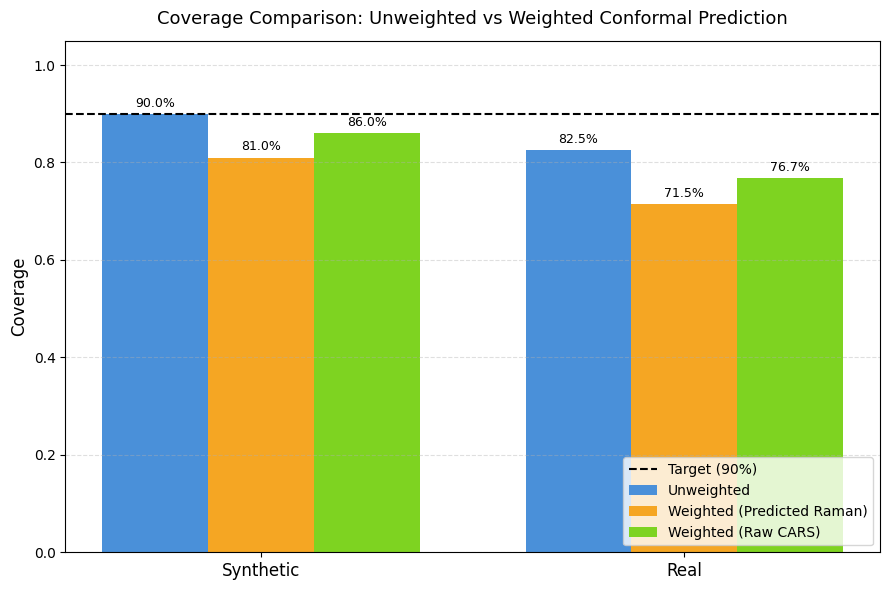

In [53]:
import matplotlib.pyplot as plt
import numpy as np

# === COMPARISON PLOT: Unweighted vs Option A vs Option B ===

# Make sure these have been computed in earlier cells:
# - q_unweighted, q_weighted_A, q_weighted_B
# - cov_syn_unweighted, cov_syn_A, cov_syn_B
# - cov_real_unweighted, cov_real_A, cov_real_B

# Data setup
labels = ["Synthetic", "Real"]
unweighted_vals = [cov_syn_unweighted, cov_real_unweighted]
option_a_vals   = [cov_syn_A, cov_real_A]
option_b_vals   = [cov_syn_B, cov_real_B]

x = np.arange(len(labels))
width = 0.25

# Create figure
fig, ax = plt.subplots(figsize=(9, 6))

# Plot three sets of bars
bars1 = ax.bar(x - width, unweighted_vals, width, label="Unweighted", color="#4A90D9")
bars2 = ax.bar(x,         option_a_vals,   width, label="Weighted (Predicted Raman)", color="#F5A623")
bars3 = ax.bar(x + width, option_b_vals,   width, label="Weighted (Raw CARS)", color="#7ED321")

# Target line
ax.axhline(1 - alpha, linestyle="--", color="black", linewidth=1.5, label=f"Target ({(1-alpha)*100:.0f}%)")

# Add value labels on top of each bar
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height*100:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=9)

# Formatting
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Coverage", fontsize=12)
ax.set_title("Coverage Comparison: Unweighted vs Weighted Conformal Prediction", fontsize=13, pad=12)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", fontsize=10, frameon=True)
ax.grid(True, axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()